In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

puzzles = pd.read_csv("all_recent_puzzles.csv")
letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

In [76]:
puzzles = puzzles[~puzzles.Puzzle.isna()].copy()

In [ ]:
(puzzles["Puzzle"][puzzles.Puzzle.apply(lambda x: "-" in x)]).value_counts().head(40)

Puzzle
CHOCOLATE-COVERED STRAWBERRIES    5
TUTTI-FRUTTI                      4
MERRY-GO-ROUND                    4
SMASH-HIT BROADWAY MUSICAL        4
KNOCK-KNOCK JOKE                  4
STRAIGHT-A STUDENT                4
HEART-SHAPED PENDANT              4
FORGET-ME-NOTS                    4
ALL-STAR TEAM                     4
SELF-HELP BOOKS                   3
FIRE-BREATHING DRAGON             3
SHORT-ORDER COOK                  3
INCREDIBLE MAN-MADE WATERWAY      3
ONE-HIT WONDER                    3
ICE-COLD LEMONADE                 3
COFFEE-TABLE BOOK                 3
CAST-IRON SKILLET                 3
WAKE ME UP BEFORE YOU GO-GO       3
WINDOW-SHOPPING                   3
ZIP-LINING THROUGH THE JUNGLE     3
NEXT-DOOR NEIGHBOR                3
WHITE-WATER RAFTING               3
WHOLESOME HOME-COOKED MEAL        3
FRONT-PAGE NEWS                   3
CARRY-ON LUGGAGE                  3
DEEP-DISH APPLE PIE               3
WALL-TO-WALL CARPET               3
FULL-LENGTH MIRROR   

In [ ]:
puzzles["Puzzle"] = puzzles.Puzzle.str.replace("  ", "")
puzzles["first_letters"] = puzzles.Puzzle.apply(
    lambda x: [a[0] for a in str(x).split(" ")] if " " in x else [str(x)[0]]
)
puzzles["words"] = puzzles.Puzzle.apply(lambda x: [a for a in str(x).split(" ")] if " " in x else [str(x)[0]])
puzzles["the"] = puzzles.words.apply(lambda x: "THE" in x)
for l in letters:
    puzzles[f"{l}_start"] = puzzles["first_letters"].apply(lambda x: l in x)
    puzzles[f"{l}_any"] = puzzles["Puzzle"].apply(lambda x: l in x)
    puzzles[f"{l}_count"] = puzzles["Puzzle"].apply(lambda x: x.count(l))

In [ ]:
puzzles["the"].mean()

0.13600333750521484

In [ ]:
sns.barplot(
    data=puzzles[puzzles.Category.isin(["What Are You Doing?"])]
    .groupby("Category")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False),
    x="variable",
    y="value",
)

plt.xticks(rotation=90)

AttributeError: 'Series' object has no attribute 'melt'

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25],
 [Text(0, 0, 'A_start'),
  Text(1, 0, 'B_start'),
  Text(2, 0, 'P_start'),
  Text(3, 0, 'F_start'),
  Text(4, 0, 'W_start'),
  Text(5, 0, 'O_start'),
  Text(6, 0, 'H_start'),
  Text(7, 0, 'T_start'),
  Text(8, 0, 'G_start'),
  Text(9, 0, 'C_start'),
  Text(10, 0, 'M_start'),
  Text(11, 0, 'I_start'),
  Text(12, 0, 'J_start'),
  Text(13, 0, 'D_start'),
  Text(14, 0, 'V_start'),
  Text(15, 0, 'Y_start'),
  Text(16, 0, 'Q_start'),
  Text(17, 0, 'S_start'),
  Text(18, 0, 'U_start'),
  Text(19, 0, 'L_start'),
  Text(20, 0, 'K_start'),
  Text(21, 0, 'E_start'),
  Text(22, 0, 'N_start'),
  Text(23, 0, 'R_start'),
  Text(24, 0, 'Z_start'),
  Text(25, 0, 'X_start')])

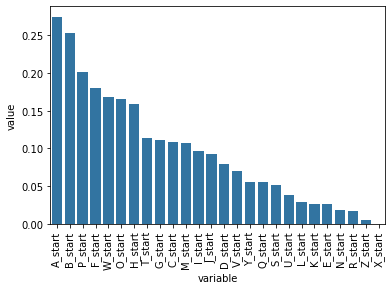

In [ ]:
sns.barplot(
    data=puzzles[puzzles.Round.isin(["BR"])]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False),
    x="variable",
    y="value",
)

plt.xticks(rotation=90)

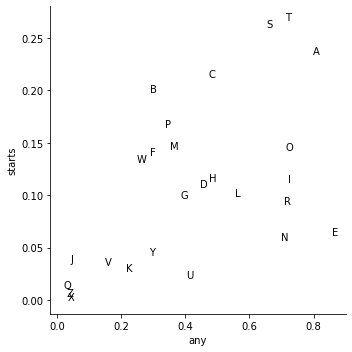

In [ ]:
starts = (
    puzzles[puzzles.Category != "What Are You Doing?"]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
starts["variable"] = starts.variable.str.replace("_start", "")
starts["starts"] = starts.pop("value")

anys = (
    puzzles[puzzles.Category != "What Are You Doing?"]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_any" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
anys["variable"] = anys.variable.str.replace("_any", "")
anys["any"] = anys.pop("value")

merged = anys.merge(starts)
sns.lmplot(data=merged, x="any", y="starts", fit_reg=False, scatter_kws={"alpha": 0})
for r in merged.itertuples():
    plt.text(r.any, r.starts, r.variable)

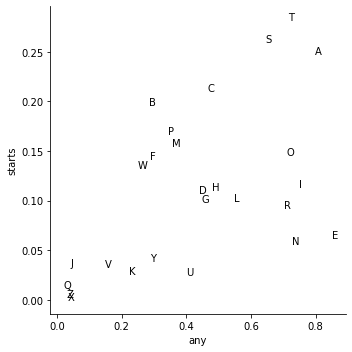

In [ ]:
starts = (
    puzzles.groupby("test")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
starts["variable"] = starts.variable.str.replace("_start", "")
starts["starts"] = starts.pop("value")

anys = (
    puzzles.groupby("test")
    .mean(numeric_only=True)[[f"{l}_any" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
anys["variable"] = anys.variable.str.replace("_any", "")
anys["any"] = anys.pop("value")

merged = anys.merge(starts)
sns.lmplot(data=merged, x="any", y="starts", fit_reg=False, scatter_kws={"alpha": 0})
for r in merged.itertuples():
    plt.text(r.any, r.starts, r.variable)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25],
 [Text(0, 0, 'A_any'),
  Text(1, 0, 'O_any'),
  Text(2, 0, 'I_any'),
  Text(3, 0, 'E_any'),
  Text(4, 0, 'N_any'),
  Text(5, 0, 'R_any'),
  Text(6, 0, 'U_any'),
  Text(7, 0, 'T_any'),
  Text(8, 0, 'G_any'),
  Text(9, 0, 'H_any'),
  Text(10, 0, 'D_any'),
  Text(11, 0, 'L_any'),
  Text(12, 0, 'Y_any'),
  Text(13, 0, 'S_any'),
  Text(14, 0, 'C_any'),
  Text(15, 0, 'P_any'),
  Text(16, 0, 'B_any'),
  Text(17, 0, 'F_any'),
  Text(18, 0, 'W_any'),
  Text(19, 0, 'M_any'),
  Text(20, 0, 'K_any'),
  Text(21, 0, 'V_any'),
  Text(22, 0, 'J_any'),
  Text(23, 0, 'Q_any'),
  Text(24, 0, 'Z_any'),
  Text(25, 0, 'X_any')])

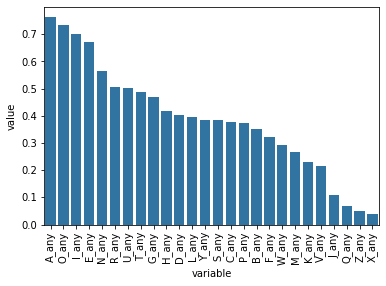

In [ ]:
sns.barplot(
    data=puzzles[puzzles.Round.isin(["BR"])]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_any" for l in letters]]
    .melt()
    .sort_values("value", ascending=False),
    x="variable",
    y="value",
)

plt.xticks(rotation=90)

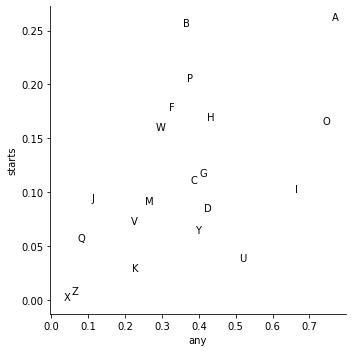

In [ ]:
starts = (
    puzzles[puzzles.Round.isin(["BR"]) & ~puzzles.Category.isin(["What Are You Doing?"])]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
starts["variable"] = starts.variable.str.replace("_start", "")
starts["starts"] = starts.pop("value")

anys = (
    puzzles[puzzles.Round.isin(["BR"]) & ~puzzles.Category.isin(["What Are You Doing?"])]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_any" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
anys["variable"] = anys.variable.str.replace("_any", "")
anys["any"] = anys.pop("value")

merged = anys.merge(starts)
sns.lmplot(data=merged, x="any", y="starts", fit_reg=False, scatter_kws={"alpha": 0})
for r in merged.itertuples():
    if r.variable in "LSRTNE":
        continue
    plt.text(r.any, r.starts, r.variable)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25],
 [Text(0, 0, 'T_start'),
  Text(1, 0, 'S_start'),
  Text(2, 0, 'A_start'),
  Text(3, 0, 'C_start'),
  Text(4, 0, 'B_start'),
  Text(5, 0, 'P_start'),
  Text(6, 0, 'M_start'),
  Text(7, 0, 'O_start'),
  Text(8, 0, 'F_start'),
  Text(9, 0, 'W_start'),
  Text(10, 0, 'I_start'),
  Text(11, 0, 'H_start'),
  Text(12, 0, 'D_start'),
  Text(13, 0, 'L_start'),
  Text(14, 0, 'G_start'),
  Text(15, 0, 'R_start'),
  Text(16, 0, 'E_start'),
  Text(17, 0, 'N_start'),
  Text(18, 0, 'Y_start'),
  Text(19, 0, 'J_start'),
  Text(20, 0, 'V_start'),
  Text(21, 0, 'K_start'),
  Text(22, 0, 'U_start'),
  Text(23, 0, 'Q_start'),
  Text(24, 0, 'Z_start'),
  Text(25, 0, 'X_start')])

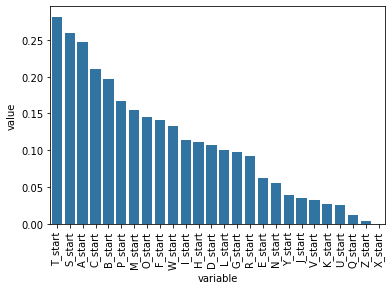

In [ ]:
puzzles["test"] = 1
sns.barplot(
    data=puzzles.groupby("test")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False),
    x="variable",
    y="value",
)

plt.xticks(rotation=90)

In [ ]:
puzzles[puzzles.Category.isin(puzzles.Category.value_counts().index[:50])].groupby("Category").mean(numeric_only=True)[
    [f"{l}_start" for l in letters]
].reset_index()[puzzles.Category.value_counts().index.values]

KeyError: "None of [Index(['Phrase', 'What Are You Doing?', 'Thing', 'Food & Drink', 'Place',\n       'Fun & Games', 'Event', 'Before & After', 'Person', 'Things',\n       ...\n       'Tennis _____', '_____ School', 'If the Shoe Fits', 'World Capitals',\n       'On the Water', '_____ Boat', 'Have A Cookie', 'Coastal _____',\n       'Artificial _____', 'Vehicles'],\n      dtype='object', length=712)] are in the [columns]"

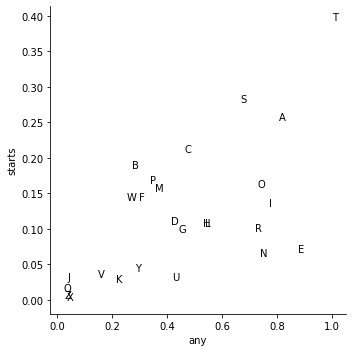

In [ ]:
starts = (
    puzzles[puzzles.T_any]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_start" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
starts["variable"] = starts.variable.str.replace("_start", "")
starts["starts"] = starts.pop("value")

anys = (
    puzzles[puzzles.T_any]
    .groupby("test")
    .mean(numeric_only=True)[[f"{l}_any" for l in letters]]
    .melt()
    .sort_values("value", ascending=False)
)
anys["variable"] = anys.variable.str.replace("_any", "")
anys["any"] = anys.pop("value")

merged = anys.merge(starts)
sns.lmplot(data=merged, x="any", y="starts", fit_reg=False, scatter_kws={"alpha": 0})
for r in merged.itertuples():
    plt.text(r.any, r.starts, r.variable)

In [ ]:
first_letters = []
for x in puzzles.Puzzle.values:
    x = x.replace("  ", " ")
    first_letters.append()